## Dataset:
Link: https://www.kaggle.com/competitions/boston-housing/data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_path = "boston-housing/train.csv"
test_path = "boston-housing/test.csv"

In [3]:
train_df = pd.read_csv(train_path)

In [4]:
train_df.columns.to_list()

['ID',
 'crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'black',
 'lstat',
 'medv']

In [5]:
FEATURE_COLUMNS = ["crim", "zn", "indus", "chas", "nox", "rm", "age", "dis", "rad", "tax", "ptratio", "black", "lstat"]

## Part 1

In [6]:
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [7]:
# Iteration-1 : simple --> model -> evaluation(model,test) --> 98%

In [8]:
train_df.shape

(333, 15)

In [9]:
def basic_summary(df):
    print("Shape of the DataFrame:", df.shape)
    print("\nData Types:\n", df.dtypes)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nStatistical Summary:\n", df.describe())

In [10]:
basic_summary(train_df)

Shape of the DataFrame: (333, 15)

Data Types:
 ID           int64
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object

Missing Values:
 ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

Statistical Summary:
                ID        crim          zn       indus        chas         nox  \
count  333.000000  333.000000  333.000000  333.000000  333.000000  333.000000   
mean   250.951952    3.360341   10.689189   11.293483    0.060060    0.557144   
std    147.859438    7.352272   22.674762    6.998123    0.237956    0.114955   
min      1.000000    0.006320    0.000000    0.740000    0.000000    0.385000   

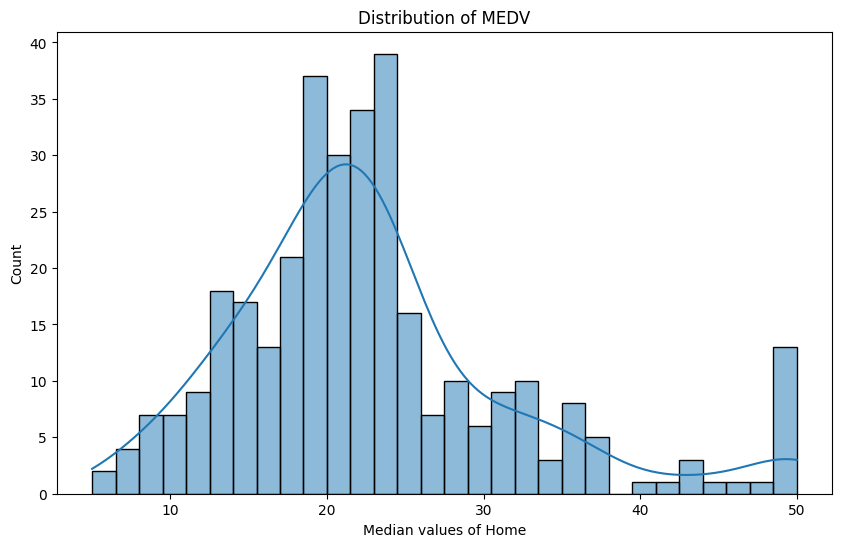

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df["medv"], bins=30, kde=True)
plt.title("Distribution of MEDV")
plt.xlabel("Median values of Home")
plt.ylabel("Count")
plt.show()

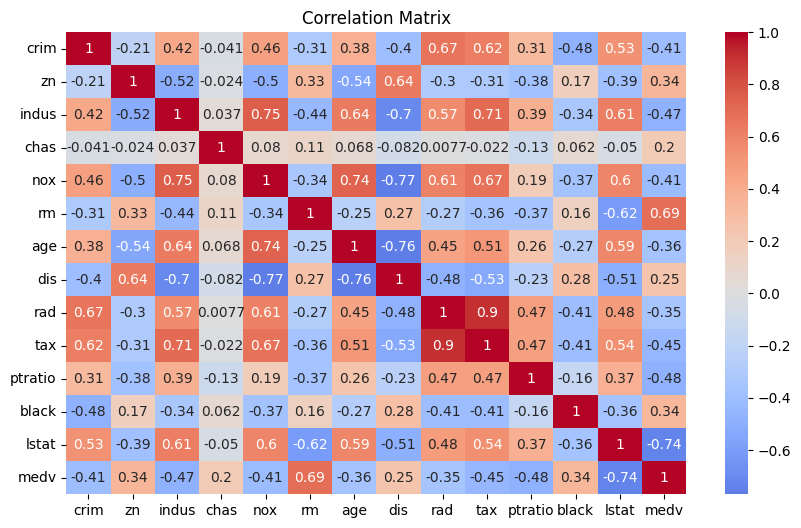

In [12]:
plt.figure(figsize=(10, 6))
corr = train_df.drop(columns=["ID"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

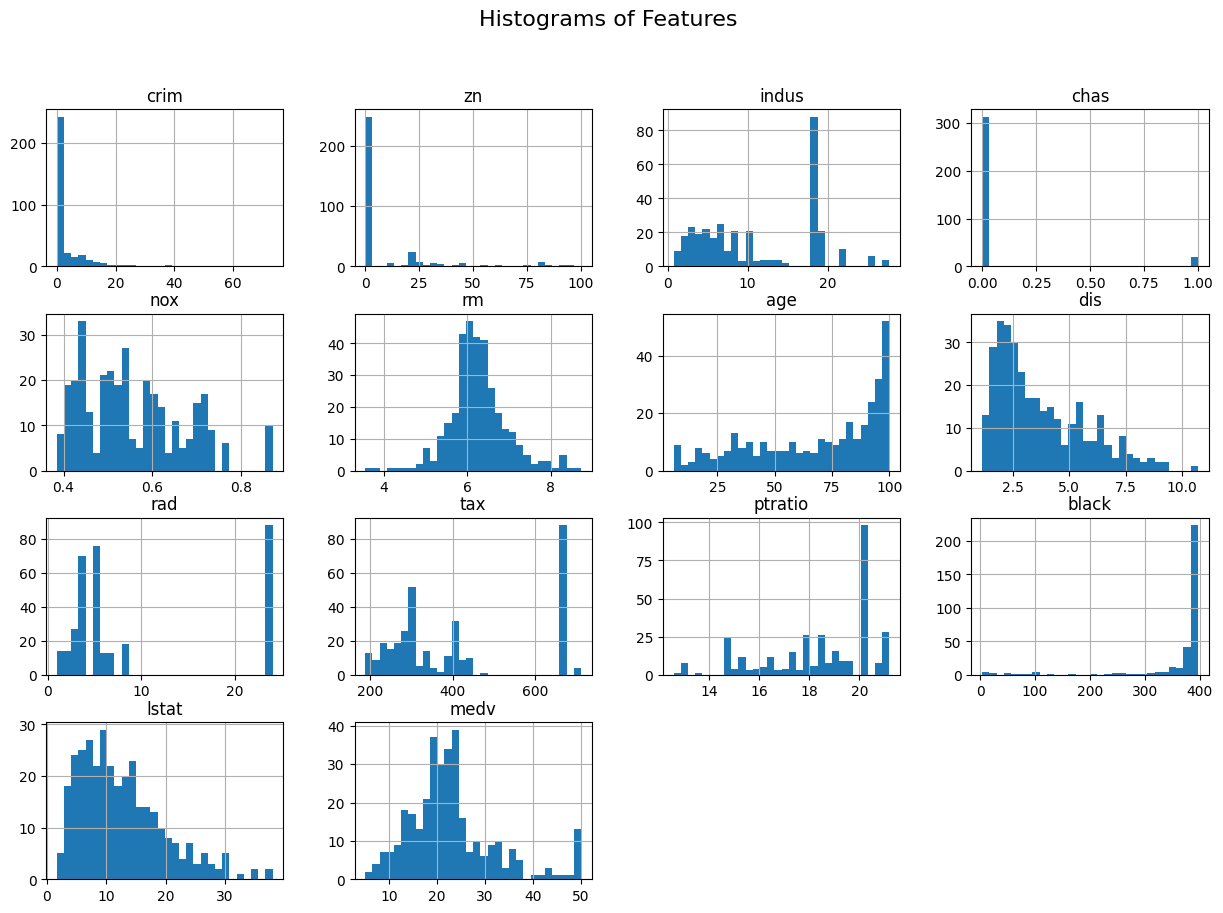

In [13]:
train_df.drop(columns=["ID"]).hist(figsize=(15, 10), bins=30)
plt.suptitle("Histograms of Features", fontsize=16)
plt.show()

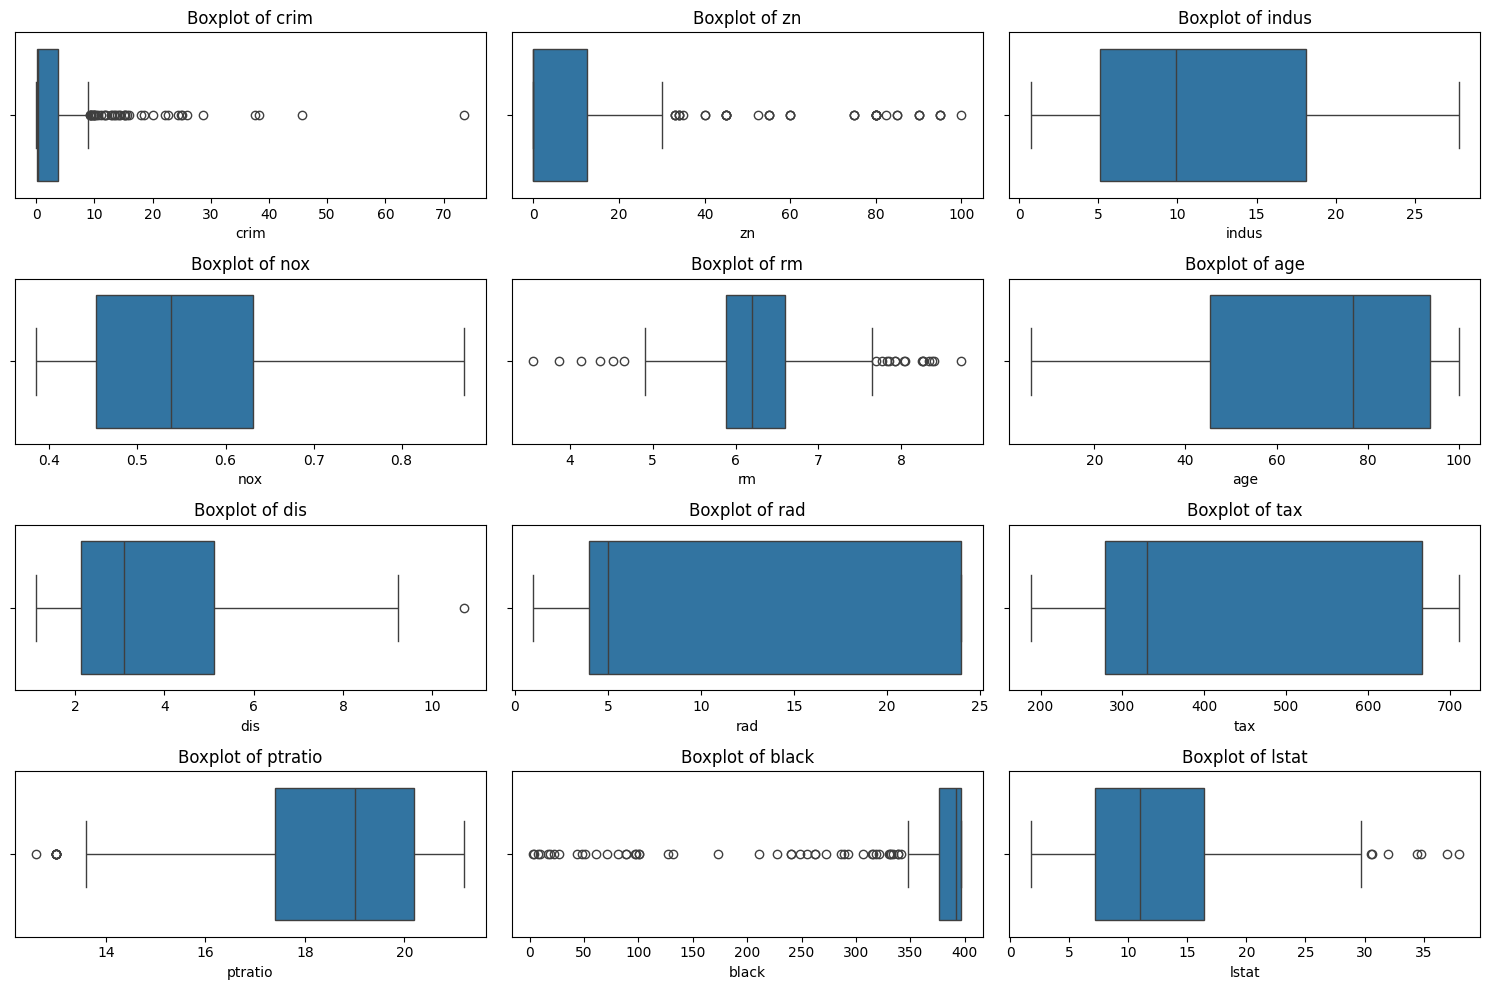

In [14]:
numeric_cols = train_df.drop(columns=["ID","chas","medv"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

## Part 2

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [16]:
x_train_full = train_df.drop(columns=["ID", "medv"])
y_train_full = train_df["medv"]

In [17]:
x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(x_train_full, y_train_full, test_size=0.3, random_state=20)

In [18]:
print(x_train_split.shape, y_train_split.shape)

(233, 13) (233,)


In [19]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

In [20]:
numeric_features = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']
categorical_features = ['chas', 'rad']

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

In [22]:
x_train_processed = preprocessor.fit_transform(x_train_split)
x_test_processed = preprocessor.transform(x_test_split)

In [23]:
print(x_train_processed.shape, x_test_processed.shape)

(233, 20) (100, 20)


## Part 3

In [24]:
# Train the model using Stochastic Gradient Descent Regressor
sgd_reg = SGDRegressor(
    max_iter=1000,
    eta0=0.01,  # learning rate
    random_state=5

)

In [25]:
sgd_reg.fit(x_train_processed, y_train_split)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",5
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


In [26]:
sgd_reg.coef_

array([-0.38380188,  0.8683008 , -0.01083271, -1.22581814,  2.90165376,
        0.05159882, -2.91223521, -1.40392135, -1.88084274,  1.22698572,
       -4.64566683,  3.25025438,  0.40018433,  3.49131974,  1.63224267,
        1.7337928 , -0.21729018,  3.04064211,  3.2847097 ,  6.0140854 ])

In [27]:
sgd_reg.intercept_

array([19.67239363])

In [28]:
# OLS
linear_reg_ols = LinearRegression()

In [29]:
linear_reg_ols.fit(x_train_processed, y_train_split)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-0.42, 1.09, 0.28,..., 6.1 , 4.74, 6.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[37.44,16.65,15.55,..., 2.74, 2. , 0.87]"


In [30]:
linear_reg_ols.coef_

array([-0.41906221,  1.0861423 ,  0.27965771, -1.45629093,  2.69048759,
        0.11201193, -3.14357969, -1.40595019, -1.987074  ,  1.16112624,
       -4.69481569,  4.07359011,  0.05348466,  4.78359877,  2.1454668 ,
        2.31251037, -0.24816454,  6.09797633,  4.73972776,  6.65977081])

In [31]:
linear_reg_ols.intercept_

np.float64(18.890267919077473)

## Test Model

In [32]:
y_test_pred = sgd_reg.predict(x_test_processed)
y_train_pred = sgd_reg.predict(x_train_processed)

In [33]:
# Evaluation
from sklearn.metrics import mean_squared_error

In [34]:
mse_train = mean_squared_error(y_train_split, y_train_pred)
mse_test = mean_squared_error(y_test_split, y_test_pred)

print(f"SGD Regressor - Train MSE: {mse_train:.2f}, Test MSE: {mse_test:.2f}")

SGD Regressor - Train MSE: 21.27, Test MSE: 23.27


In [35]:
def plot_actual_vs_predicted_lines(y_actual, y_predicted):
    plt.figure(figsize=(8, 6))
    if isinstance(y_actual, pd.Series):
        y_actual = y_actual.values

    plt.plot(y_actual, label="Actual Values", color="blue", linewidth=2)
    plt.plot(y_predicted, label="Predicted Values", color="red", linewidth=2, linestyle='--')

    plt.title("Actual vs Predicted Values")
    plt.xlabel("Data Index")
    plt.ylabel("Median Value of Home (MEDV)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

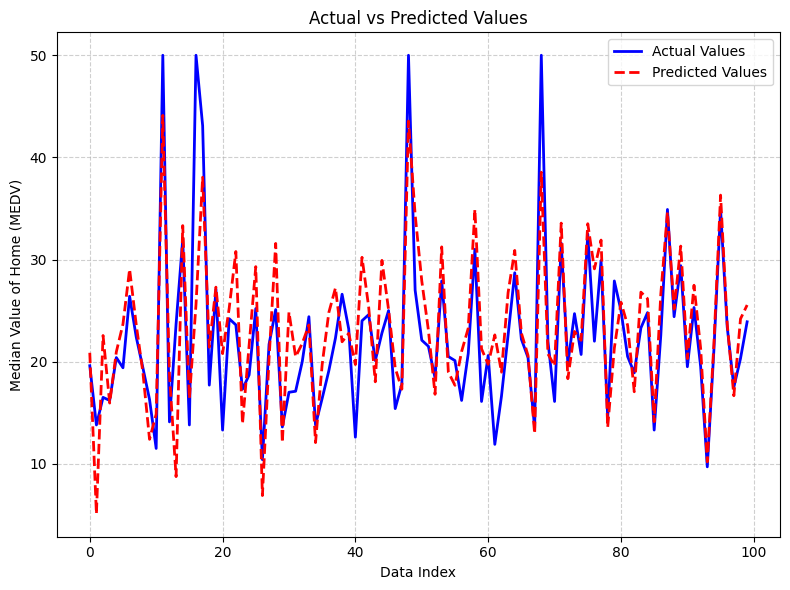

In [36]:
plot_actual_vs_predicted_lines(y_test_split, y_test_pred)

## Save Artefacts

In [37]:
import joblib

In [38]:
model_filename = 'artefacts/final_sgd_reg_model.joblib'
preprocessor_filename = 'artefacts/data_preprocessor.joblib'

In [39]:
joblib.dump(sgd_reg, model_filename)
joblib.dump(preprocessor, preprocessor_filename)

['artefacts/data_preprocessor.joblib']

## L1 & L2 Regularization

In [43]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np
from sklearn.metrics import r2_score

In [45]:
# ------Lasso Reg.-------
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(x_train_processed, y_train_split)

# Train pred
y_train_pred_lasso = lasso.predict(x_train_processed)
# Test pred
y_test_pred_lasso = lasso.predict(x_test_processed)

# Train eval
mse_train_lasso = mean_squared_error(y_train_split, y_train_pred_lasso)
lasso_rmse = np.sqrt(mse_train_lasso)
lasso_r2 = r2_score(y_train_split, y_train_pred_lasso)

# Test eval
mse_test_lasso = mean_squared_error(y_test_split, y_test_pred_lasso)
lasso_rmse_test = np.sqrt(mse_test_lasso)
lasso_r2_test = r2_score(y_test_split, y_test_pred_lasso)

print("Lasso Regression:")
print(f"Train RMSE: {lasso_rmse}")
print(f"Train R2: {lasso_r2}")
print(f"Test RMSE: {lasso_rmse_test}")
print(f"Test R2: {lasso_r2_test}")
print(f"MSE (TRAIN): {mse_train_lasso}")
print(f"MSE (TEST): {mse_test_lasso}")    
print(f"MSE (TRAIN) (SGD): {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")

Lasso Regression:
Train RMSE: 4.782206667443605
Train R2: 0.7517970999849473
Test RMSE: 5.058960772675943
Test R2: 0.6032900220897899
MSE (TRAIN): 22.869500610142065
MSE (TEST): 25.593084099473973
MSE (TRAIN) (SGD): 21.269784140725992
MSE (TEST) (SGD): 23.27343170963786


In [47]:
print(lasso.intercept_)
print(lasso.coef_)

22.739795621626715
[-0.          0.42519719 -0.27871721 -0.48908958  3.15234668 -0.
 -2.2330226  -0.         -1.48482703  1.12972199 -4.70574559  2.82898037
 -0.          1.05697634 -0.12591943 -0.         -1.20109854  0.10963518
  0.17519315  0.        ]


In [46]:
# ------Ridge Reg.-------
ridge = Ridge(alpha=0.1, random_state=42, max_iter=10000)
ridge.fit(x_train_processed, y_train_split)

# Train pred
y_train_pred_ridge = ridge.predict(x_train_processed)
# Test pred
y_test_pred_ridge = ridge.predict(x_test_processed)

# Train eval
mse_train_ridge = mean_squared_error(y_train_split, y_train_pred_ridge)
ridge_rmse = np.sqrt(mse_train_ridge)
ridge_r2 = r2_score(y_train_split, y_train_pred_ridge)

# Test eval
mse_test_ridge = mean_squared_error(y_test_split, y_test_pred_ridge)
ridge_rmse_test = np.sqrt(mse_test_ridge)
ridge_r2_test = r2_score(y_test_split, y_test_pred_ridge)

print("Ridge Regression:")
print(f"Train RMSE: {ridge_rmse}")
print(f"Train R2: {ridge_r2}")
print(f"Test RMSE: {ridge_rmse_test}")
print(f"Test R2: {ridge_r2_test}")
print(f"MSE (TRAIN): {mse_train_ridge}")
print(f"MSE (TEST): {mse_test_ridge}")    
print(f"MSE (TRAIN) (SGD): {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")

Ridge Regression:
Train RMSE: 4.573026171667459
Train R2: 0.7730357035828805
Test RMSE: 4.852879101090306
Test R2: 0.6349524450293649
MSE (TRAIN): 20.912568366755536
MSE (TEST): 23.550435569799056
MSE (TRAIN) (SGD): 21.269784140725992
MSE (TEST) (SGD): 23.27343170963786


In [48]:
print(ridge.intercept_)
print(ridge.coef_)

19.295332186241676
[-0.41196805  1.06338908  0.25360608 -1.43810962  2.69825872  0.10901886
 -3.13188851 -1.34218954 -1.97890383  1.16115127 -4.68907369  4.06132783
 -0.25621989  4.41022095  1.77503264  1.93777793 -0.6288661   5.66730637
  4.33559311  6.14927017]
